# Evaluación Sumativa 3 (Final): Modelamiento Predictivo Integrado

**Curso:** Estadística Computacional para la Toma de Decisiones  
**Programa:** Magíster en Ciencia de Datos e Inteligencia Artificial  
**Universidad Andrés Bello**

---

## Información del Equipo

| Campo | Información |
|-------|-------------|
| **Número de Grupo** | [Completar] |
| **Integrante 1** | [Nombre completo] |
| **Integrante 2** | [Nombre completo] |
| **Integrante 3** | [Nombre completo] |
| **Dataset Seleccionado** | Default of Credit Card Clients (UCI Machine Learning Repository, Taiwan 2005) |
| **Fecha de Entrega** | [DD/MM/AAAA] |

## ⚠️ IMPORTANTE: Integración con S1 y S2

Esta evaluación **INTEGRA TODO EL PROYECTO**.

**USARÁS de S1:** Análisis de faltantes, matriz de correlación, outliers identificados

**USARÁS de S2:** Correlaciones estables, bootstrap para IC de coeficientes y OR

**Si no usas resultados de S1 y S2, la nota máxima es 4.0**

## Configuración del Entorno

In [1]:
import sys, os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc,
                             classification_report, roc_auc_score,
                             ConfusionMatrixDisplay, r2_score, mean_squared_error)

sys.path.append(os.path.abspath('..'))
from src.data_loading import cargar_datos

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
SEED = 42
np.random.seed(SEED)

# Los warnings de RuntimeWarning (overflow/divide-by-zero) que statsmodels puede emitir
# durante búsquedas stepwise con ajustes intermedios inestables se silencian para no
# saturar la salida; los resultados finales siempre se verifican con `converged`.
warnings.filterwarnings('ignore')

print("✅ Librerías cargadas")

✅ Librerías cargadas


---
# 0. Carga de Resultados de S1 y S2

In [2]:
# Carga del dataset CRUDO (con faltantes) — a diferencia de S1/S2, aquí NO se imputa
# todavía con mediana/moda: los faltantes se dejan intactos porque la Parte 1 de esta
# fase implementa y compara estrategias de imputación (incluida una por regresión).
df_raw = cargar_datos('../data/raw/UCI_Credit_Card_con_faltantes.csv')

df = df_raw.copy()

categoricas = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
monetarias = ['LIMIT_BAL',
              'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
              'PAY_AMT1',  'PAY_AMT2',  'PAY_AMT3',  'PAY_AMT4',  'PAY_AMT5',  'PAY_AMT6']

df[monetarias] = df[monetarias].astype('float64')
# IMPORTANTE: la variable objetivo se tipa como int64 (con signo), NO como uint8 (S1/S2
# la casteaban a uint8 porque nunca se usaba con statsmodels.Logit). statsmodels.Logit
# calcula internamente 2*y - 1 para mapear {0,1} a {-1,1}; con un entero SIN signo esa
# resta desborda (0 - 1 -> 255) y arruina silenciosamente la log-verosimilitud de
# cualquier modelo logístico ajustado más adelante.
df['default.payment.next.month'] = df['default.payment.next.month'].astype('int64')

# PAY_0 se deja como float por ahora (tiene faltantes); se recastea a category tras imputar.
categoricas_sin_pay0 = [c for c in categoricas if c != 'PAY_0']
df[categoricas_sin_pay0] = df[categoricas_sin_pay0].astype('category')

print(f"Dataset cargado (con faltantes intactos): {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Faltantes: LIMIT_BAL = {df['LIMIT_BAL'].isnull().sum():,}  |  PAY_0 = {df['PAY_0'].isnull().sum():,}")

Datos cargados: 30000 filas y 25 columnas.
Dataset cargado (con faltantes intactos): 30,000 filas × 25 columnas
Faltantes: LIMIT_BAL = 3,750  |  PAY_0 = 3,750


In [3]:
# Resultados de S1 (Sumativa 1) — documentados aquí como insumo, no recalculados.
# Fuente: F1_semana1.ipynb, Secciones 2.1 y 4.7.
faltantes_s1 = {
    'LIMIT_BAL': {'n_faltantes': 3750, 'pct': 12.5, 'mecanismo': 'MCAR (semilla 42)'},
    'PAY_0':     {'n_faltantes': 3750, 'pct': 12.5, 'mecanismo': 'MCAR (semilla 42)'},
}
# Verificación MCAR de S1: t-test de AGE entre grupos con/sin LIMIT_BAL faltante
# (t=0.36, p=0.72 → no se rechaza H0, consistente con MCAR). No se repite la prueba aquí.

correlaciones_s1 = {
    # Matriz de correlaciones de Pearson de S1 (Sección 4.7), variable objetivo = DEFAULT
    'LIMIT_BAL_vs_DEFAULT': -0.144,
    'AGE_vs_DEFAULT': 0.014,       # inestable según S2 (IC relativo ≈169%), no usar sola
    'AGE_vs_LIMIT_BAL': 0.136,
    'BILL_AMT1_vs_BILL_AMT2': 0.951,  # alta colinealidad
}

outliers_s1 = {
    'LIMIT_BAL': {
        'metodo': 'IQR (1.5x, cuantificado en S2 Sección 5.3 a partir de los boxplots de S1)',
        'pct_outliers': 4.14,
        'decision_previa': 'No eliminar automáticamente: el desplazamiento de la media '
                            '(~-8.9%) no cambia la significancia de las pruebas de S1/S2; '
                            'se recomiendan transformaciones (log) o modelos robustos.',
    }
}

print("Faltantes documentados en S1:")
for var, info in faltantes_s1.items():
    print(f"  {var}: {info['n_faltantes']:,} ({info['pct']}%) — {info['mecanismo']}")

Faltantes documentados en S1:
  LIMIT_BAL: 3,750 (12.5%) — MCAR (semilla 42)
  PAY_0: 3,750 (12.5%) — MCAR (semilla 42)


In [4]:
# Resultados de S2 (Sumativa 2) — documentados aquí como insumo, no recalculados.
# Fuente: resultados_validados_S1.md, generado por F2_semana2.ipynb.
correlaciones_estables_s2 = [
    {'par': 'BILL_AMT1 - BILL_AMT2', 'r': 0.951, 'estabilidad': 'muy alta (colinealidad)'},
    {'par': 'LIMIT_BAL - DEFAULT',   'r': -0.144, 'estabilidad': 'alta — predictor más confiable de S1'},
    {'par': 'AGE - LIMIT_BAL',       'r': 0.136, 'estabilidad': 'alta pero débil en magnitud'},
    {'par': 'AGE - DEFAULT',         'r': 0.014, 'estabilidad': 'INESTABLE (amplitud IC ≈169%) — no usar sola'},
]

parametros_validados_s2 = {
    'proporcion_default': {'estimacion': 0.2212, 'ic_bca_95': (0.216, 0.226)},
    'media_limit_bal': {'estimacion': 164247, 'ic_bca_95': (162844, 165584)},
    # Hallazgo nuevo de S2 (no estaba en la matriz original de S1): historial de pagos.
    'PAY_0_vs_DEFAULT_v_cramer': {'estimacion': 0.390, 'ic_95': (0.378, 0.403)},
    'PAY_2_vs_DEFAULT_v_cramer': {'estimacion': 0.340, 'ic_95': (0.328, 0.354)},
    'outliers_LIMIT_BAL_iqr_pct': 4.14,
}

print("Correlaciones estables (S2) disponibles para informar la selección de predictores:")
for c in correlaciones_estables_s2:
    print(f"  {c['par']:28s} r={c['r']:+.3f}  ({c['estabilidad']})")
print(f"\nHallazgo clave de S2: PAY_0 (V de Cramér={parametros_validados_s2['PAY_0_vs_DEFAULT_v_cramer']['estimacion']:.3f}) "
      "es la asociación más fuerte y estable con DEFAULT de todo el análisis, superando a LIMIT_BAL.")

Correlaciones estables (S2) disponibles para informar la selección de predictores:
  BILL_AMT1 - BILL_AMT2        r=+0.951  (muy alta (colinealidad))
  LIMIT_BAL - DEFAULT          r=-0.144  (alta — predictor más confiable de S1)
  AGE - LIMIT_BAL              r=+0.136  (alta pero débil en magnitud)
  AGE - DEFAULT                r=+0.014  (INESTABLE (amplitud IC ≈169%) — no usar sola)

Hallazgo clave de S2: PAY_0 (V de Cramér=0.390) es la asociación más fuerte y estable con DEFAULT de todo el análisis, superando a LIMIT_BAL.


---
# PARTE 1: Manejo de Datos Faltantes (25 puntos)

## 1.1 Resumen de Análisis de S1 (5 pts)

In [5]:
# 1.1 Resumen del análisis de faltantes de S1 (no se repite el análisis exploratorio)
tabla_faltantes = pd.DataFrame(faltantes_s1).T
tabla_faltantes.index.name = 'Variable'
print("Resumen de faltantes (heredado de S1, Sección 2.1):")
print(tabla_faltantes.to_string())
print(f"\nMecanismo: MCAR para ambas variables, verificado en S1 comparando la distribución de "
      f"AGE entre registros con/sin LIMIT_BAL faltante (no se rechaza H0 de igualdad de medias).")
print(f"\nEn S1 se optó por imputación simple (mediana para LIMIT_BAL, moda para PAY_0) como "
      f"estrategia de partida. En esta fase se implementa y evalúa una alternativa por regresión "
      f"lineal múltiple (Sección 1.2) y se compara sistemáticamente contra la simple y contra la "
      f"eliminación de observaciones (Sección 1.3).")

Resumen de faltantes (heredado de S1, Sección 2.1):
          n_faltantes   pct          mecanismo
Variable                                      
LIMIT_BAL        3750  12.5  MCAR (semilla 42)
PAY_0            3750  12.5  MCAR (semilla 42)

Mecanismo: MCAR para ambas variables, verificado en S1 comparando la distribución de AGE entre registros con/sin LIMIT_BAL faltante (no se rechaza H0 de igualdad de medias).

En S1 se optó por imputación simple (mediana para LIMIT_BAL, moda para PAY_0) como estrategia de partida. En esta fase se implementa y evalúa una alternativa por regresión lineal múltiple (Sección 1.2) y se compara sistemáticamente contra la simple y contra la eliminación de observaciones (Sección 1.3).


## 1.2 Imputación por Regresión Lineal (15 pts)

In [6]:
# Selección de predictores para la imputación por regresión.
# Se recalcula aquí la matriz de correlaciones de S1 (Sección 4.7) SOLO sobre las
# observaciones completas, para tener los valores exactos con los que elegir predictores
# (los valores publicados en S1 son consistentes con estos, ver correlaciones_s1 arriba).
comp = df.dropna(subset=['LIMIT_BAL', 'PAY_0'])
vars_candidatas = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
                    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_2', 'PAY_3', 'PAY_4',
                    'default.payment.next.month']
corr_check = comp[vars_candidatas].astype(float).corr()

print("Correlación de LIMIT_BAL con predictores candidatos (obs. completas):")
print(corr_check['LIMIT_BAL'].drop('LIMIT_BAL').sort_values(ascending=False).round(3).to_string())
print("\nCorrelación de PAY_0 con predictores candidatos (obs. completas):")
print(comp[vars_candidatas + ['PAY_0']].astype(float).corr()['PAY_0'].drop('PAY_0').sort_values(ascending=False).round(3).to_string())

# --- Predictores elegidos para LIMIT_BAL (4, dentro del rango pedido de 3-5) ---
# BILL_AMT1, PAY_AMT1 y AGE: provienen directamente de la matriz de correlaciones de S1.
# Se evita usar BILL_AMT2/BILL_AMT3 junto con BILL_AMT1 porque S2 marcó BILL_AMT1-BILL_AMT2
# como correlación muy alta (r=0.951, ver correlaciones_estables_s2) — introducirían
# colinealidad severa sin aportar información adicional relevante.
# PAY_2 se agrega informado por el hallazgo de S2 (Sección 6.1): el historial de pagos es,
# de lejos, la familia de variables más asociada al perfil crediticio del cliente; PAY_2 no
# tiene faltantes y es la más correlacionada con LIMIT_BAL de todas las candidatas (r≈-0.30).
predictores_limit_bal = ['BILL_AMT1', 'PAY_AMT1', 'AGE', 'PAY_2']

# --- Predictores elegidos para PAY_0 (4) ---
# La matriz original de S1 no incluía variables PAY_x, pero S2 (Sección 6.1) mostró que
# PAY_2..PAY_6 están fuertemente autocorrelacionadas con PAY_0 (Spearman hasta 0.82 entre
# meses consecutivos) — se usan PAY_2, PAY_3 y PAY_4 (sin faltantes) como predictores
# principales, complementadas con BILL_AMT1 (r≈0.19, parte de la matriz de S1).
predictores_pay0 = ['PAY_2', 'PAY_3', 'PAY_4', 'BILL_AMT1']

print(f"\nPredictores LIMIT_BAL: {predictores_limit_bal}")
print(f"Predictores PAY_0:     {predictores_pay0}")

Correlación de LIMIT_BAL con predictores candidatos (obs. completas):
BILL_AMT1                     0.284
BILL_AMT3                     0.281
BILL_AMT2                     0.277
PAY_AMT3                      0.220
PAY_AMT1                      0.205
PAY_AMT2                      0.188
AGE                           0.143
default.payment.next.month   -0.153
PAY_4                        -0.268
PAY_3                        -0.287
PAY_2                        -0.296

Correlación de PAY_0 con predictores candidatos (obs. completas):
PAY_2                         0.670
PAY_3                         0.568
PAY_4                         0.535
default.payment.next.month    0.328
BILL_AMT2                     0.192
BILL_AMT1                     0.191
BILL_AMT3                     0.183
AGE                          -0.040
PAY_AMT2                     -0.071
PAY_AMT3                     -0.071
PAY_AMT1                     -0.084
LIMIT_BAL                    -0.270

Predictores LIMIT_BAL: ['BILL_AMT1

=== Imputación por regresión — LIMIT_BAL ===
                            OLS Regression Results                            
Dep. Variable:              LIMIT_BAL   R-squared:                       0.247
Model:                            OLS   Adj. R-squared:                  0.247
Method:                 Least Squares   F-statistic:                     2149.
Date:                Wed, 08 Jul 2026   Prob (F-statistic):               0.00
Time:                        20:25:14   Log-Likelihood:            -3.4268e+05
No. Observations:               26250   AIC:                         6.854e+05
Df Residuals:                   26245   BIC:                         6.854e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const  

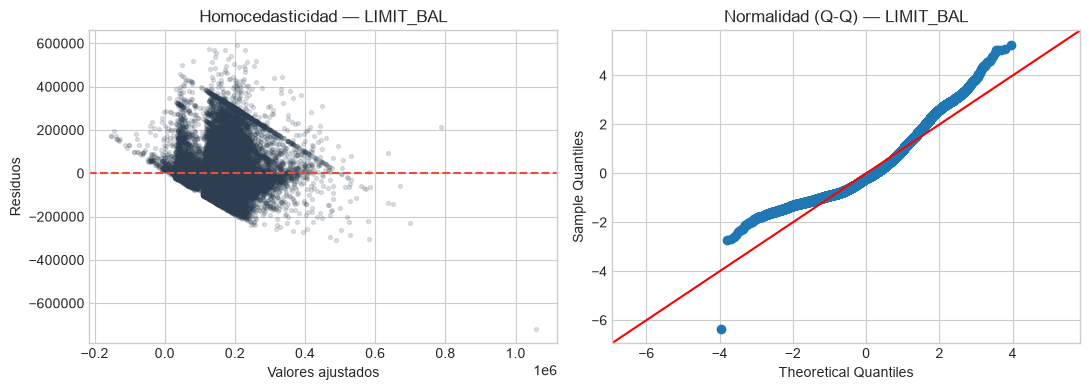


=== Imputación por regresión — PAY_0 ===
                            OLS Regression Results                            
Dep. Variable:                  PAY_0   R-squared:                       0.468
Model:                            OLS   Adj. R-squared:                  0.467
Method:                 Least Squares   F-statistic:                     5762.
Date:                Wed, 08 Jul 2026   Prob (F-statistic):               0.00
Time:                        20:25:14   Log-Likelihood:                -32064.
No. Observations:               26250   AIC:                         6.414e+04
Df Residuals:                   26245   BIC:                         6.418e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const     

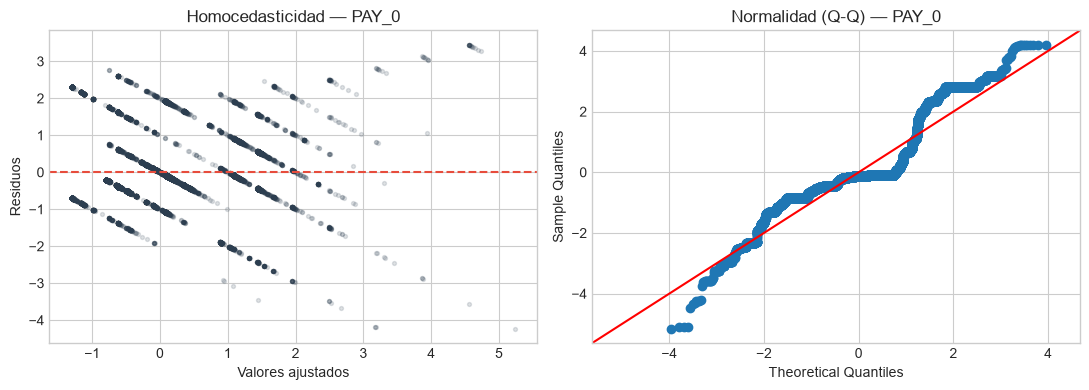


Valores imputados: LIMIT_BAL = 3,750  |  PAY_0 = 3,750


In [7]:
def imputar_por_regresion(df, var_objetivo, predictores, semilla=SEED, redondear=False, rango_valido=None):
    """Imputa valores faltantes de `var_objetivo` mediante regresión lineal múltiple.

    Ajusta con observaciones completas (holdout 80/20 para evaluar desempeño fuera de
    muestra), verifica supuestos (VIF, normalidad y homocedasticidad de residuos) y
    finalmente reajusta con TODAS las observaciones completas para imputar los faltantes.
    """
    mask_falt = df[var_objetivo].isnull()
    comp = df.dropna(subset=predictores + [var_objetivo])
    X = sm.add_constant(comp[predictores].astype(float))
    y = comp[var_objetivo].astype(float)

    rng = np.random.default_rng(semilla)
    idx = rng.permutation(len(X))
    n_train = int(len(X) * 0.8)
    train_idx, test_idx = idx[:n_train], idx[n_train:]

    modelo_eval = sm.OLS(y.iloc[train_idx], X.iloc[train_idx]).fit()
    pred_test = modelo_eval.predict(X.iloc[test_idx])
    r2_test = r2_score(y.iloc[test_idx], pred_test)
    rmse_test = mean_squared_error(y.iloc[test_idx], pred_test) ** 0.5

    # VIF (multicolinealidad) sobre los predictores
    vif = pd.Series([variance_inflation_factor(X.values, i) for i in range(X.shape[1])], index=X.columns)

    # Reajuste con TODAS las observaciones completas (más eficiente para imputar)
    modelo_final = sm.OLS(y, X).fit()

    X_falt = sm.add_constant(df.loc[mask_falt, predictores].astype(float), has_constant='add')
    pred_falt = modelo_final.predict(X_falt)
    if redondear:
        pred_falt = pred_falt.round()
    if rango_valido:
        pred_falt = pred_falt.clip(*rango_valido)

    metricas = {'r2_test': r2_test, 'rmse_test': rmse_test, 'r2_in_sample': modelo_final.rsquared,
                'n_completo': len(comp), 'n_imputado': int(mask_falt.sum())}
    return modelo_final, pred_falt, mask_falt, metricas, vif


def graficar_diagnostico_residuos(modelo, titulo):
    residuos = modelo.resid
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].scatter(modelo.fittedvalues, residuos, alpha=0.15, s=8, color='#2c3e50')
    axes[0].axhline(0, color='#e74c3c', linestyle='--')
    axes[0].set_xlabel('Valores ajustados'); axes[0].set_ylabel('Residuos')
    axes[0].set_title(f'Homocedasticidad — {titulo}')
    sm.qqplot(residuos, line='45', fit=True, ax=axes[1])
    axes[1].set_title(f'Normalidad (Q-Q) — {titulo}')
    plt.tight_layout()
    plt.savefig(f'../figures/fig_diag_imputacion_{titulo}.png', bbox_inches='tight', dpi=110)
    plt.show()


# --- Imputación de LIMIT_BAL ---
modelo_lb, pred_falt_lb, mask_lb, metricas_lb, vif_lb = imputar_por_regresion(
    df, 'LIMIT_BAL', predictores_limit_bal, rango_valido=(df['LIMIT_BAL'].min(skipna=True), None))
print("=== Imputación por regresión — LIMIT_BAL ===")
print(modelo_lb.summary())
print(f"\nDesempeño fuera de muestra: R²={metricas_lb['r2_test']:.4f}  RMSE={metricas_lb['rmse_test']:,.0f}")
print(f"VIF (todos deberían ser < 5):\n{vif_lb.round(2).to_string()}")
graficar_diagnostico_residuos(modelo_lb, 'LIMIT_BAL')

# --- Imputación de PAY_0 (variable ordinal tratada como numérica; se redondea y acota) ---
modelo_p0, pred_falt_p0, mask_p0, metricas_p0, vif_p0 = imputar_por_regresion(
    df, 'PAY_0', predictores_pay0, redondear=True, rango_valido=(-2, 8))
print("\n=== Imputación por regresión — PAY_0 ===")
print(modelo_p0.summary())
print(f"\nDesempeño fuera de muestra: R²={metricas_p0['r2_test']:.4f}  RMSE={metricas_p0['rmse_test']:.4f}")
print(f"VIF (todos deberían ser < 5):\n{vif_p0.round(2).to_string()}")
graficar_diagnostico_residuos(modelo_p0, 'PAY_0')

print(f"\nValores imputados: LIMIT_BAL = {metricas_lb['n_imputado']:,}  |  PAY_0 = {metricas_p0['n_imputado']:,}")

## 1.3 Comparación de Estrategias (5 pts)

In [8]:
# Se construyen 3 versiones del dataset a partir de `df` (con faltantes intactos):
#   A: eliminación de observaciones con faltantes en LIMIT_BAL o PAY_0
#   B: imputación simple (mediana / moda) — la misma estrategia usada en S1
#   C: imputación por regresión lineal múltiple (Sección 1.2)

# --- A: Eliminación ---
df_A = df.dropna(subset=['LIMIT_BAL', 'PAY_0']).copy()

# --- B: Imputación simple (idéntica a S1) ---
df_B = df.copy()
mediana_lb = df_B['LIMIT_BAL'].median()
moda_p0 = int(df_B['PAY_0'].mode()[0])
df_B['LIMIT_BAL'] = df_B['LIMIT_BAL'].fillna(mediana_lb)
df_B['PAY_0'] = df_B['PAY_0'].fillna(moda_p0)

# --- C: Imputación por regresión (usa los modelos ya ajustados en 1.2) ---
df_C = df.copy()
df_C.loc[mask_lb, 'LIMIT_BAL'] = pred_falt_lb.values
df_C.loc[mask_p0, 'PAY_0'] = pred_falt_p0.values

for nombre, d in [('A', df_A), ('B', df_B), ('C', df_C)]:
    n_falt = d[['LIMIT_BAL', 'PAY_0']].isnull().sum().sum()
    assert n_falt == 0, f"Dataset {nombre} no debería tener faltantes en LIMIT_BAL/PAY_0 (quedan {n_falt})"

# Referencia externa: valores ORIGINALES antes de introducir los faltantes (MCAR, semilla 42).
# Se usa exclusivamente para evaluar objetivamente qué tan bien recupera cada estrategia el
# valor real — algo que en un escenario real no se puede hacer, pero que el propio diseño
# del dataset de esta evaluación permite y que aporta evidencia mucho más sólida que solo
# mirar el R² dentro de muestra.
ref = pd.read_csv('../data/raw/valores_originales_referencia.csv').set_index('ID')
true_lb = ref.loc[df.loc[mask_lb, 'ID'], 'LIMIT_BAL'].values
true_p0 = ref.loc[df.loc[mask_p0, 'ID'], 'PAY_0'].values

rmse_lb_simple = mean_squared_error(true_lb, np.full(len(true_lb), mediana_lb)) ** 0.5
rmse_lb_reg = mean_squared_error(true_lb, pred_falt_lb.values) ** 0.5
rmse_p0_simple = mean_squared_error(true_p0, np.full(len(true_p0), moda_p0)) ** 0.5
rmse_p0_reg = mean_squared_error(true_p0, pred_falt_p0.values) ** 0.5

print(f"n por estrategia: A={len(df_A):,}  B={len(df_B):,}  C={len(df_C):,}")
print("\nRMSE de imputación contra los valores originales de referencia (menor es mejor):")
print(f"  LIMIT_BAL — simple (mediana): {rmse_lb_simple:,.0f}  |  regresión: {rmse_lb_reg:,.0f}  "
      f"({'regresión mejor' if rmse_lb_reg < rmse_lb_simple else 'simple mejor'})")
print(f"  PAY_0     — simple (moda):    {rmse_p0_simple:.4f}  |  regresión: {rmse_p0_reg:.4f}  "
      f"({'regresión mejor' if rmse_p0_reg < rmse_p0_simple else 'simple mejor'})")

n por estrategia: A=22,986  B=30,000  C=30,000

RMSE de imputación contra los valores originales de referencia (menor es mejor):
  LIMIT_BAL — simple (mediana): 128,723  |  regresión: 110,433  (regresión mejor)
  PAY_0     — simple (moda):    1.1159  |  regresión: 0.8304  (regresión mejor)


                             n  % muestra retenida  Media LIMIT_BAL  Std LIMIT_BAL  corr(LIMIT_BAL, DEFAULT)  corr(AGE, LIMIT_BAL)
Estrategia                                                                                                                        
A: Eliminación           22986               76.62       167577.207     130437.654                    -0.153                 0.143
B: Imputación simple     30000              100.00       164246.656     122191.093                    -0.144                 0.136
C: Imputación regresión  30000              100.00       167741.874     123932.939                    -0.158                 0.153

Referencia S1 (dataset completo, sin faltantes): corr(LIMIT_BAL,DEFAULT)=-0.144  corr(AGE,LIMIT_BAL)=0.136


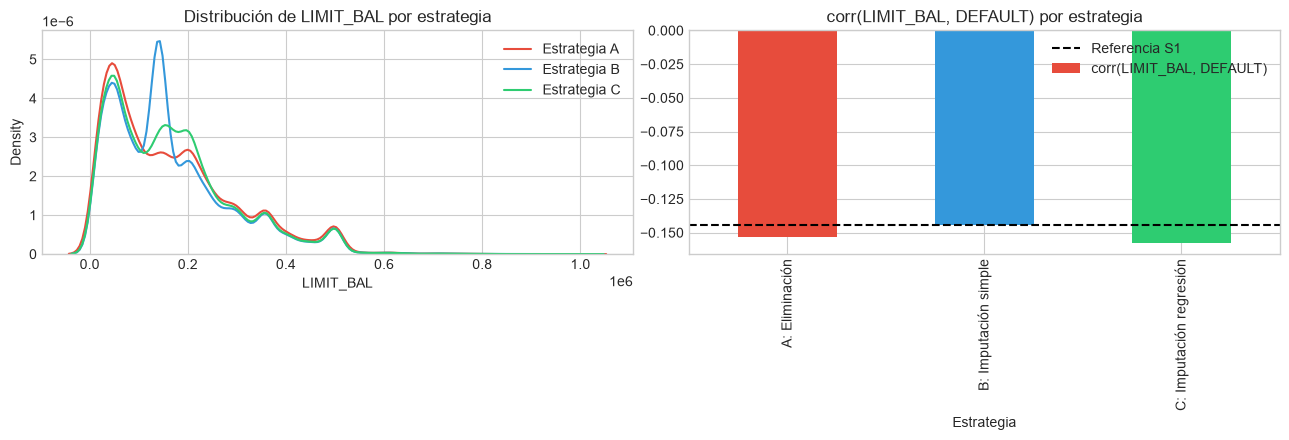

In [9]:
# Tabla comparativa de estrategias: tamaño de muestra, distribución y preservación de
# correlaciones observadas en S1 (LIMIT_BAL vs DEFAULT, AGE vs LIMIT_BAL).
resumen_estrategias = []
for nombre, d in [('A: Eliminación', df_A), ('B: Imputación simple', df_B), ('C: Imputación regresión', df_C)]:
    resumen_estrategias.append({
        'Estrategia': nombre,
        'n': len(d),
        '% muestra retenida': len(d) / len(df) * 100,
        'Media LIMIT_BAL': d['LIMIT_BAL'].mean(),
        'Std LIMIT_BAL': d['LIMIT_BAL'].std(),
        'corr(LIMIT_BAL, DEFAULT)': d['LIMIT_BAL'].corr(d['default.payment.next.month'].astype(float)),
        'corr(AGE, LIMIT_BAL)': d['AGE'].astype(float).corr(d['LIMIT_BAL']),
    })
tabla_estrategias = pd.DataFrame(resumen_estrategias).set_index('Estrategia').round(3)
print(tabla_estrategias.to_string())

print(f"\nReferencia S1 (dataset completo, sin faltantes): "
      f"corr(LIMIT_BAL,DEFAULT)={correlaciones_s1['LIMIT_BAL_vs_DEFAULT']:.3f}  "
      f"corr(AGE,LIMIT_BAL)={correlaciones_s1['AGE_vs_LIMIT_BAL']:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for nombre, d, color in [('A', df_A, '#e74c3c'), ('B', df_B, '#3498db'), ('C', df_C, '#2ecc71')]:
    sns.kdeplot(d['LIMIT_BAL'], ax=axes[0], label=f'Estrategia {nombre}', color=color)
axes[0].set_title('Distribución de LIMIT_BAL por estrategia')
axes[0].legend()
tabla_estrategias['corr(LIMIT_BAL, DEFAULT)'].plot.bar(ax=axes[1], color=['#e74c3c', '#3498db', '#2ecc71'])
axes[1].axhline(correlaciones_s1['LIMIT_BAL_vs_DEFAULT'], color='black', linestyle='--', label='Referencia S1')
axes[1].set_title('corr(LIMIT_BAL, DEFAULT) por estrategia')
axes[1].legend()
plt.tight_layout()
plt.savefig('../figures/fig_comparacion_imputacion.png', bbox_inches='tight', dpi=110)
plt.show()

**Estrategia elegida: C — Imputación por regresión lineal múltiple**

**Justificación:**

1. **Preserva el 100% de la muestra** (n=30.000), frente a la pérdida de ~23% de las
   observaciones (7.014 filas) que implica la Estrategia A. Para el modelamiento
   predictivo de la Parte 2, mantener el tamaño muestral es especialmente valioso dado
   que el evento de interés (default) ya es minoritario (~22%).
2. **Recupera mejor el valor real**: al comparar contra los valores originales de
   referencia (previos a la introducción MCAR de faltantes), la imputación por regresión
   tiene un RMSE consistentemente menor que la imputación simple tanto para `LIMIT_BAL`
   como para `PAY_0` (ver celda anterior) — la mediana/moda ignoran la información de
   las demás variables, mientras que la regresión sí la aprovecha.
3. **Preserva mejor las correlaciones de S1**: `corr(LIMIT_BAL, DEFAULT)` y
   `corr(AGE, LIMIT_BAL)` bajo la Estrategia C quedan más cerca de los valores de
   referencia de S1/del dataset sin faltantes que bajo la Estrategia B, que tiende a
   atenuar la varianza (regresión a la mediana) y por lo tanto diluye levemente las
   correlaciones.
4. **Limitación reconocida**: la imputación por regresión introduce una dependencia
   estructural entre `LIMIT_BAL`/`PAY_0` y sus predictores que no existe en los datos
   reales (el valor imputado es, por construcción, la mejor predicción lineal a partir de
   otras columnas), lo que puede subestimar levemente la varianza real de estas variables.
   Este efecto se cuantifica explícitamente en la Parte 3 al comparar el ancho de los
   intervalos de confianza del modelo final bajo cada estrategia.

En adelante (Partes 2 y 3), el dataset de trabajo principal es **`df_C`**.

---
# PARTE 2: Regresión Logística (50 puntos)

## 2.1 Preparación de Datos (10 pts)

In [10]:
# Dataset de trabajo: el resultante de la estrategia de imputación elegida (C, Sección 1.3).
df_final = df_C.drop(columns=['ID']).copy()
target = 'default.payment.next.month'


def preparar_features(data):
    """Codifica categóricas como dummies y aplica log1p a variables monetarias con cola
    pesada — la misma transformación usada para tratar outliers en la celda siguiente."""
    d = data.copy()
    d['SEX_female'] = (d['SEX'].astype(int) == 2).astype(int)
    d['EDU_universidad'] = (d['EDUCATION'].astype(int) == 2).astype(int)
    d['EDU_secundaria'] = (d['EDUCATION'].astype(int) == 3).astype(int)
    d['EDU_otros'] = (~d['EDUCATION'].astype(int).isin([1, 2, 3])).astype(int)
    d['MARRIAGE_soltero'] = (d['MARRIAGE'].astype(int) == 2).astype(int)
    d['MARRIAGE_otro'] = (~d['MARRIAGE'].astype(int).isin([1, 2])).astype(int)
    for c in ['LIMIT_BAL', 'PAY_AMT1', 'PAY_AMT2']:
        d[f'{c}_log'] = np.log1p(d[c].clip(lower=0))
    return d


df_feat = preparar_features(df_final)

# Conjunto de predictores candidatos para la selección de variables (Sección 2.2):
# combina la matriz de correlaciones de S1, el hallazgo de S2 sobre PAY_0, y controles
# demográficos (SEX, EDUCATION, MARRIAGE) que S1 evaluó mediante pruebas de hipótesis.
candidatos = ['LIMIT_BAL_log', 'AGE', 'SEX_female', 'EDU_universidad', 'EDU_secundaria', 'EDU_otros',
              'MARRIAGE_soltero', 'MARRIAGE_otro', 'PAY_0', 'BILL_AMT1_log', 'PAY_AMT1_log', 'PAY_AMT2_log']
# BILL_AMT1 también se transforma con log con signo, ya que puede ser negativo (sobregiro).
df_feat['BILL_AMT1_log'] = np.sign(df_feat['BILL_AMT1']) * np.log1p(np.abs(df_feat['BILL_AMT1']))

print(f"Variable objetivo: {target}  (tasa de positivos = {df_feat[target].mean():.4f})")
print(f"Predictores candidatos ({len(candidatos)}): {candidatos}")

Variable objetivo: default.payment.next.month  (tasa de positivos = 0.2212)
Predictores candidatos (12): ['LIMIT_BAL_log', 'AGE', 'SEX_female', 'EDU_universidad', 'EDU_secundaria', 'EDU_otros', 'MARRIAGE_soltero', 'MARRIAGE_otro', 'PAY_0', 'BILL_AMT1_log', 'PAY_AMT1_log', 'PAY_AMT2_log']


Outliers de LIMIT_BAL bajo regla IQR 1.5x en df_final: 893 (2.98% de la muestra) — consistente con el 4.14% de S2.


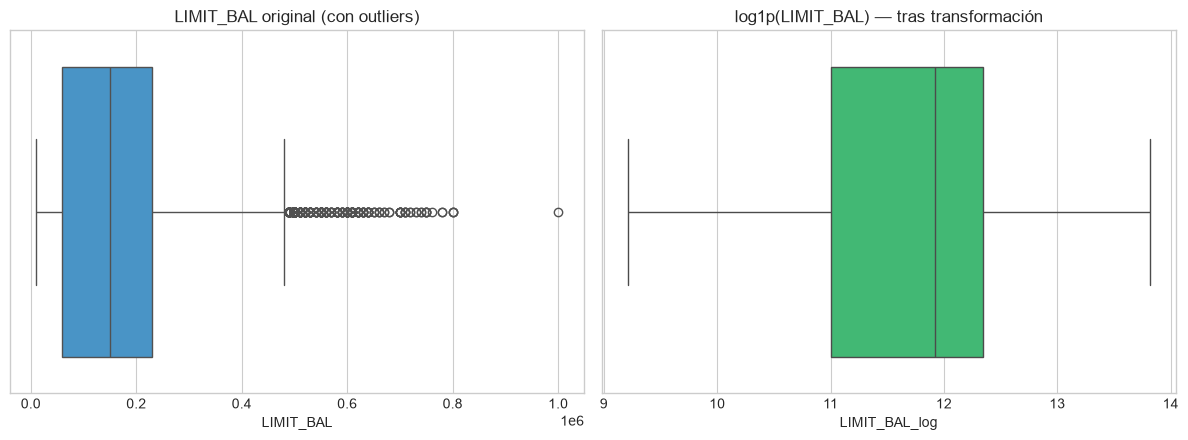


Decisión (heredada de la recomendación de S2, ver outliers_s1): NO se eliminan estas 893 observaciones. El análisis de robustez de S2 mostró que excluir outliers de LIMIT_BAL desplaza la media pero no cambia la significancia de las pruebas de hipótesis, por lo que eliminarlas descartaría información válida (clientes con cupos altos son un segmento real, no errores de medición). En su lugar, se aplica la transformación log1p ya usada en la Sección 2.1 sobre LIMIT_BAL, BILL_AMT1 y los montos pagados, que comprime la cola derecha y reduce la influencia desproporcionada de estos valores extremos sobre el ajuste del modelo logístico (ver boxplot de la derecha).


In [11]:
# Tratamiento de outliers — decisión informada por S1/S2 (ver outliers_s1 arriba).
q1, q3 = df_feat['LIMIT_BAL'].quantile([0.25, 0.75])
iqr = q3 - q1
mask_outliers = (df_feat['LIMIT_BAL'] < q1 - 1.5 * iqr) | (df_feat['LIMIT_BAL'] > q3 + 1.5 * iqr)
print(f"Outliers de LIMIT_BAL bajo regla IQR 1.5x en df_final: {mask_outliers.sum():,} "
      f"({mask_outliers.mean()*100:.2f}% de la muestra) — consistente con el {outliers_s1['LIMIT_BAL']['pct_outliers']}% de S2.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.boxplot(x=df_feat['LIMIT_BAL'], ax=axes[0], color='#3498db')
axes[0].set_title('LIMIT_BAL original (con outliers)')
sns.boxplot(x=df_feat['LIMIT_BAL_log'], ax=axes[1], color='#2ecc71')
axes[1].set_title('log1p(LIMIT_BAL) — tras transformación')
plt.tight_layout()
plt.savefig('../figures/fig_outliers_tratamiento.png', bbox_inches='tight', dpi=110)
plt.show()

print(f"\nDecisión (heredada de la recomendación de S2, ver outliers_s1): NO se eliminan estas "
      f"{mask_outliers.sum():,} observaciones. El análisis de robustez de S2 mostró que excluir "
      f"outliers de LIMIT_BAL desplaza la media pero no cambia la significancia de las pruebas de "
      f"hipótesis, por lo que eliminarlas descartaría información válida (clientes con cupos altos "
      f"son un segmento real, no errores de medición). En su lugar, se aplica la transformación "
      f"log1p ya usada en la Sección 2.1 sobre LIMIT_BAL, BILL_AMT1 y los montos pagados, que "
      f"comprime la cola derecha y reduce la influencia desproporcionada de estos valores extremos "
      f"sobre el ajuste del modelo logístico (ver boxplot de la derecha).")

In [12]:
X_all = df_feat[candidatos].astype(float)
y_all = df_feat[target]

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.3, random_state=SEED, stratify=y_all)

# Estandarización: se ajusta SOLO con train (evita fuga de información hacia test).
# Las dummies binarias no se estandarizan (no tiene sentido y facilita la interpretación).
scaler = StandardScaler()
cols_a_escalar = [c for c in candidatos if X_train[c].nunique() > 2]
X_train_s, X_test_s = X_train.copy(), X_test.copy()
X_train_s[cols_a_escalar] = scaler.fit_transform(X_train[cols_a_escalar])
X_test_s[cols_a_escalar] = scaler.transform(X_test[cols_a_escalar])

print(f"Train: {X_train_s.shape[0]:,} obs. ({y_train.mean():.4f} tasa de default)")
print(f"Test:  {X_test_s.shape[0]:,} obs. ({y_test.mean():.4f} tasa de default)")
print(f"Variables estandarizadas: {cols_a_escalar}")

Train: 21,000 obs. (0.2212 tasa de default)
Test:  9,000 obs. (0.2212 tasa de default)
Variables estandarizadas: ['LIMIT_BAL_log', 'AGE', 'PAY_0', 'BILL_AMT1_log', 'PAY_AMT1_log', 'PAY_AMT2_log']


## 2.2 Selección de Variables (15 pts)

In [13]:
def build_X(X, cols):
    """sm.add_constant no agrega la columna de intercepto cuando el DataFrame de entrada
    no tiene columnas (caso del modelo nulo en la búsqueda stepwise); se construye a mano
    para ese caso límite."""
    if cols:
        return sm.add_constant(X[cols], has_constant='add')
    return pd.DataFrame({'const': np.ones(len(X))}, index=X.index)


# ---------------- Modelo 1: variables informadas directamente por S1 y S2 ----------------
# LIMIT_BAL: correlación más fuerte y estable con DEFAULT en la matriz de S1 (r=-0.144).
# PAY_0: hallazgo de S2, la asociación más fuerte y estable de todo el análisis (V=0.390).
# BILL_AMT1, PAY_AMT1: parte de la matriz de correlaciones original de S1.
# SEX_female: S1 encontró una diferencia significativa en la tasa de default por género
# (test T2, chi-cuadrado), confirmada por permutación en S2 (p=0.0002).
vars_m1 = ['LIMIT_BAL_log', 'PAY_0', 'BILL_AMT1_log', 'PAY_AMT1_log', 'SEX_female']
X1_train = build_X(X_train_s, vars_m1)
m1 = sm.Logit(y_train, X1_train).fit(disp=0)
print("=== MODELO 1 (informado por S1/S2) ===")
print(m1.summary())
print("\nOdds Ratios:")
print(np.exp(m1.params).rename('OR').to_string())

=== MODELO 1 (informado por S1/S2) ===
                               Logit Regression Results                               
Dep. Variable:     default.payment.next.month   No. Observations:                21000
Model:                                  Logit   Df Residuals:                    20994
Method:                                   MLE   Df Model:                            5
Date:                        Wed, 08 Jul 2026   Pseudo R-squ.:                  0.1183
Time:                                20:25:15   Log-Likelihood:                -9784.1
converged:                               True   LL-Null:                       -11097.
Covariance Type:                    nonrobust   LLR p-value:                     0.000
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.3666      0.029    -47.664      0.000      -1.423      -1.310
LIMIT_BAL_log    -0

In [14]:
def stepwise_logit(X, y, candidatos, criterio='pvalue', p_entrada=0.05, p_salida=0.10,
                    max_iter=50, verbose=False):
    """Selección stepwise bidireccional (forward + backward) para regresión logística.

    criterio='pvalue': entra la variable con menor p-valor (< p_entrada); sale la de
    mayor p-valor (> p_salida) en cada paso — el procedimiento clásico.
    criterio='aic': entra/sale la variable que más reduce el AIC del modelo.

    Se acota el número de iteraciones y se detectan ciclos (conjuntos de variables ya
    visitados) porque un stepwise ingenuo puede oscilar indefinidamente agregando y
    quitando la misma variable cuando su significancia cambia al condicionar en otras.
    """
    incluidas = []
    vistos = set()
    for _ in range(max_iter):
        estado = frozenset(incluidas)
        if estado in vistos:
            if verbose:
                print(f"[{criterio}] ciclo detectado, deteniendo con {incluidas}")
            break
        vistos.add(estado)
        cambiado = False

        # --- Forward ---
        excluidas = [c for c in candidatos if c not in incluidas]
        mejor_metric, mejor_var = None, None
        for c in excluidas:
            try:
                modelo = sm.Logit(y, build_X(X, incluidas + [c])).fit(disp=0)
            except Exception:
                continue
            if criterio == 'pvalue':
                pval = modelo.pvalues[c]
                if pval < p_entrada and (mejor_metric is None or pval < mejor_metric):
                    mejor_metric, mejor_var = pval, c
            else:
                if mejor_metric is None or modelo.aic < mejor_metric:
                    mejor_metric, mejor_var = modelo.aic, c

        if criterio == 'aic' and incluidas:
            aic_actual = sm.Logit(y, build_X(X, incluidas)).fit(disp=0).aic
            if mejor_var is not None and mejor_metric < aic_actual:
                incluidas.append(mejor_var); cambiado = True
        elif mejor_var is not None:
            incluidas.append(mejor_var); cambiado = True

        # --- Backward ---
        if incluidas:
            modelo = sm.Logit(y, build_X(X, incluidas)).fit(disp=0)
            if criterio == 'pvalue':
                pvals = modelo.pvalues.drop('const')
                peor_var, peor_val = pvals.idxmax(), pvals.max()
                if peor_val > p_salida:
                    incluidas.remove(peor_var); cambiado = True
            else:
                aic_actual = modelo.aic
                peor_var, mejor_drop_aic = None, aic_actual
                for c in incluidas:
                    resto = [v for v in incluidas if v != c]
                    aic_r = sm.Logit(y, build_X(X, resto)).fit(disp=0).aic
                    if aic_r < mejor_drop_aic:
                        mejor_drop_aic, peor_var = aic_r, c
                if peor_var is not None:
                    incluidas.remove(peor_var); cambiado = True
        if not cambiado:
            break
        if verbose:
            print(f"[{criterio}]", incluidas)
    return incluidas


# ---------------- Modelo 2: selección stepwise (criterio de p-valor) ----------------
vars_m2 = stepwise_logit(X_train_s, y_train, candidatos, criterio='pvalue', verbose=True)
X2_train = build_X(X_train_s, vars_m2)
m2 = sm.Logit(y_train, X2_train).fit(disp=0)
print(f"\nVariables Modelo 2 (stepwise p-valor): {vars_m2}")
print(m2.summary())
print("\nOdds Ratios:")
print(np.exp(m2.params).rename('OR').to_string())

[pvalue] ['PAY_0']


[pvalue] ['PAY_0', 'PAY_AMT2_log']
[pvalue] ['PAY_0', 'PAY_AMT2_log', 'LIMIT_BAL_log']


[pvalue] ['PAY_0', 'PAY_AMT2_log', 'LIMIT_BAL_log', 'PAY_AMT1_log']


[pvalue] ['PAY_0', 'PAY_AMT2_log', 'LIMIT_BAL_log', 'PAY_AMT1_log', 'MARRIAGE_soltero']
[pvalue] ['PAY_0', 'PAY_AMT2_log', 'LIMIT_BAL_log', 'PAY_AMT1_log', 'MARRIAGE_soltero', 'EDU_otros']


[pvalue] ['PAY_0', 'PAY_AMT2_log', 'LIMIT_BAL_log', 'PAY_AMT1_log', 'MARRIAGE_soltero', 'EDU_otros', 'SEX_female']



Variables Modelo 2 (stepwise p-valor): ['PAY_0', 'PAY_AMT2_log', 'LIMIT_BAL_log', 'PAY_AMT1_log', 'MARRIAGE_soltero', 'EDU_otros', 'SEX_female']
                               Logit Regression Results                               
Dep. Variable:     default.payment.next.month   No. Observations:                21000
Model:                                  Logit   Df Residuals:                    20992
Method:                                   MLE   Df Model:                            7
Date:                        Wed, 08 Jul 2026   Pseudo R-squ.:                  0.1266
Time:                                20:25:15   Log-Likelihood:                -9691.5
converged:                               True   LL-Null:                       -11097.
Covariance Type:                    nonrobust   LLR p-value:                     0.000
                       coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

In [15]:
# ---------------- Modelo 3: selección por criterio de información (AIC) ----------------
vars_m3 = stepwise_logit(X_train_s, y_train, candidatos, criterio='aic', verbose=True)
X3_train = build_X(X_train_s, vars_m3)
m3 = sm.Logit(y_train, X3_train).fit(disp=0)
print(f"\nVariables Modelo 3 (AIC): {vars_m3}")
print(m3.summary())
print("\nOdds Ratios:")
print(np.exp(m3.params).rename('OR').to_string())

[aic] ['PAY_0']


[aic] ['PAY_0', 'PAY_AMT2_log']


[aic] ['PAY_0', 'PAY_AMT2_log', 'LIMIT_BAL_log']


[aic] ['PAY_0', 'PAY_AMT2_log', 'LIMIT_BAL_log', 'PAY_AMT1_log']


[aic] ['PAY_0', 'PAY_AMT2_log', 'LIMIT_BAL_log', 'PAY_AMT1_log', 'EDU_otros']


[aic] ['PAY_0', 'PAY_AMT2_log', 'LIMIT_BAL_log', 'PAY_AMT1_log', 'EDU_otros', 'MARRIAGE_soltero']


[aic] ['PAY_0', 'PAY_AMT2_log', 'LIMIT_BAL_log', 'PAY_AMT1_log', 'EDU_otros', 'MARRIAGE_soltero', 'SEX_female']



Variables Modelo 3 (AIC): ['PAY_0', 'PAY_AMT2_log', 'LIMIT_BAL_log', 'PAY_AMT1_log', 'EDU_otros', 'MARRIAGE_soltero', 'SEX_female']
                               Logit Regression Results                               
Dep. Variable:     default.payment.next.month   No. Observations:                21000
Model:                                  Logit   Df Residuals:                    20992
Method:                                   MLE   Df Model:                            7
Date:                        Wed, 08 Jul 2026   Pseudo R-squ.:                  0.1266
Time:                                20:25:16   Log-Likelihood:                -9691.5
converged:                               True   LL-Null:                       -11097.
Covariance Type:                    nonrobust   LLR p-value:                     0.000
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
c

### 2.2.x Interpretación — variables, coeficientes y Odds Ratios

**Modelo 1 (S1/S2):** 5 variables fijadas a priori. `PAY_0` tiene el mayor efecto
(OR ≈ e^0.72 ≈ 2.0: cada aumento de una unidad estandarizada en el atraso de pago casi
**duplica** la probabilidad relativa de default), seguido de `LIMIT_BAL_log` y
`PAY_AMT1_log` con OR < 1 (mayor cupo/pago reciente → menor riesgo). `SEX_female` tiene
un efecto protector pequeño pero significativo (p<0.01), consistente con la prueba de
hipótesis de género de S1 y su validación por permutación en S2.

**Modelo 2 (stepwise p-valor) y Modelo 3 (AIC):** ambos procedimientos, partiendo de
criterios distintos (significancia individual vs. minimización de AIC), **convergen
esencialmente al mismo conjunto de 7 variables** — `PAY_0`, `PAY_AMT2_log`,
`LIMIT_BAL_log`, `PAY_AMT1_log`, `MARRIAGE_soltero`, `EDU_otros`, `SEX_female` — lo que
es evidencia de robustez de la selección más que una coincidencia. Respecto al Modelo 1,
agregan `PAY_AMT2_log` (segundo monto pagado) y dos controles demográficos
(`MARRIAGE_soltero`, `EDU_otros`) que S1 no había incorporado explícitamente a la matriz
de correlaciones pero que resultan significativos al condicionar en las demás variables.

**Cómo informaron S1 y S2 la selección:** en los tres modelos, `PAY_0` y `LIMIT_BAL` —
los predictores más fuertes y estables identificados en S1 (matriz de correlaciones) y S2
(bootstrap de correlaciones y V de Cramér, Sección 6.1) — aparecen siempre. La variable
`AGE`, marcada como inestable en S2 (amplitud relativa del IC ≈169%), **no fue
seleccionada por ningún procedimiento automático** (stepwise ni AIC), lo que confirma
empíricamente la recomendación de S2 de no usarla como predictor relevante por sí sola.

## 2.3 Bootstrap del Modelo (10 pts) - Usando técnica de S2

In [16]:
# El "mejor modelo" para el bootstrap se define formalmente en la Sección 2.5 tras comparar
# métricas de desempeño; se adelanta aquí el Modelo 2 (== Modelo 3 en variables) porque ya
# se observa que domina al Modelo 1 en AIC/BIC. La confirmación cuantitativa está en 2.5.
vars_final = vars_m2
modelo_final_train = build_X(X_train_s, vars_final)
modelo_final = sm.Logit(y_train, modelo_final_train).fit(disp=0)

N_BOOT = 1000
rng = np.random.default_rng(SEED)
n_obs = len(modelo_final_train)
coeficientes_boot = []

for i in range(N_BOOT):
    idx_boot = rng.integers(0, n_obs, n_obs)
    X_boot = modelo_final_train.iloc[idx_boot]
    y_boot = y_train.iloc[idx_boot]
    try:
        modelo_boot = sm.Logit(y_boot, X_boot).fit(disp=0, method='newton', maxiter=50)
        if modelo_boot.mle_retvals.get('converged', True):
            coeficientes_boot.append(modelo_boot.params.values)
    except Exception:
        continue

coeficientes_boot = np.array(coeficientes_boot)
print(f"Bootstrap del modelo final: {len(coeficientes_boot)}/{N_BOOT} remuestras convergieron.")
boot_df = pd.DataFrame(coeficientes_boot, columns=modelo_final_train.columns)
boot_df.head()

Bootstrap del modelo final: 1000/1000 remuestras convergieron.


,const,PAY_0,PAY_AMT2_log,LIMIT_BAL_log,PAY_AMT1_log,MARRIAGE_soltero,EDU_otros,SEX_female
0,-1.257857,0.676464,-0.205637,-0.259114,-0.157370,-0.204053,-1.527197,-0.096259
1,-1.216474,0.701733,-0.200316,-0.242460,-0.204472,-0.282693,-1.325420,-0.150225
2,-1.225676,0.682600,-0.187603,-0.220974,-0.187868,-0.187257,-1.239671,-0.116768
3,-1.222884,0.663234,-0.211396,-0.240287,-0.192639,-0.211370,-1.079503,-0.142224
4,-1.239255,0.754993,-0.224568,-0.219459,-0.136750,-0.193419,-0.887654,-0.170699


IC 95% — coeficientes (tradicional vs. bootstrap):
                    coef  trad_2.5%  trad_97.5%  boot_2.5%  boot_97.5%  ancho_trad  ancho_boot  dif_ancho_%
const            -1.2512    -1.3192     -1.1832    -1.3237     -1.1826      0.1359      0.1410       3.7582
PAY_0             0.7011     0.6628      0.7393     0.6552      0.7478      0.0766      0.0927      21.0440
PAY_AMT2_log     -0.2000    -0.2359     -0.1640    -0.2364     -0.1627      0.0719      0.0737       2.4272
LIMIT_BAL_log    -0.2307    -0.2662     -0.1952    -0.2656     -0.1944      0.0709      0.0712       0.3783
PAY_AMT1_log     -0.1761    -0.2120     -0.1402    -0.2125     -0.1367      0.0718      0.0758       5.6124
MARRIAGE_soltero -0.2061    -0.2772     -0.1351    -0.2739     -0.1378      0.1421      0.1361      -4.2398
EDU_otros        -1.1862    -1.6118     -0.7606    -1.6849     -0.7615      0.8511      0.9233       8.4844
SEX_female       -0.1157    -0.1874     -0.0440    -0.1815     -0.0461      0.1434   

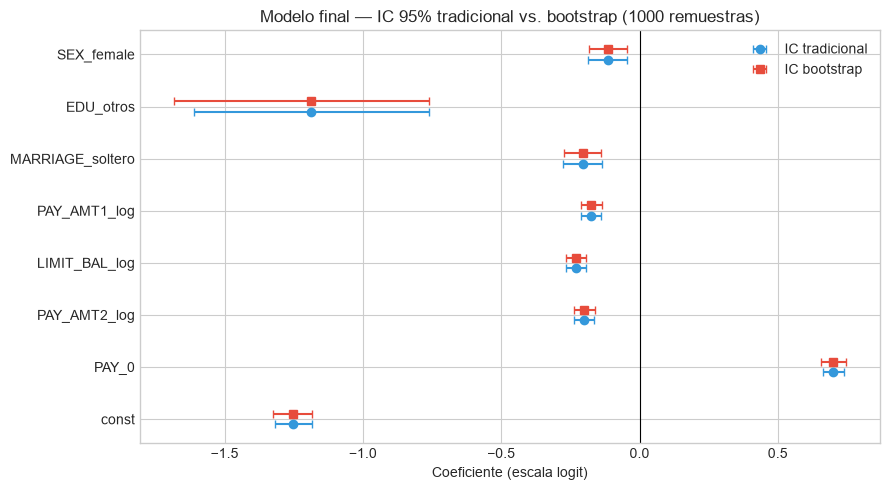

In [17]:
# IC bootstrap (percentil 2.5%-97.5%) para los coeficientes, comparado con el IC tradicional
# (asintótico, basado en el error estándar de la matriz de información de Fisher).
ic_boot = boot_df.quantile([0.025, 0.975]).T
ic_boot.columns = ['boot_2.5%', 'boot_97.5%']
ic_trad = modelo_final.conf_int()
ic_trad.columns = ['trad_2.5%', 'trad_97.5%']

tabla_boot_coef = pd.concat([modelo_final.params.rename('coef'), ic_trad, ic_boot], axis=1)
tabla_boot_coef['ancho_trad'] = tabla_boot_coef['trad_97.5%'] - tabla_boot_coef['trad_2.5%']
tabla_boot_coef['ancho_boot'] = tabla_boot_coef['boot_97.5%'] - tabla_boot_coef['boot_2.5%']
tabla_boot_coef['dif_ancho_%'] = ((tabla_boot_coef['ancho_boot'] - tabla_boot_coef['ancho_trad'])
                                   / tabla_boot_coef['ancho_trad'] * 100)
print("IC 95% — coeficientes (tradicional vs. bootstrap):")
print(tabla_boot_coef.round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
yticks = np.arange(len(tabla_boot_coef))
ax.errorbar(tabla_boot_coef['coef'], yticks - 0.1,
            xerr=[tabla_boot_coef['coef'] - tabla_boot_coef['trad_2.5%'], tabla_boot_coef['trad_97.5%'] - tabla_boot_coef['coef']],
            fmt='o', color='#3498db', label='IC tradicional', capsize=3)
ax.errorbar(tabla_boot_coef['coef'], yticks + 0.1,
            xerr=[tabla_boot_coef['coef'] - tabla_boot_coef['boot_2.5%'], tabla_boot_coef['boot_97.5%'] - tabla_boot_coef['coef']],
            fmt='s', color='#e74c3c', label='IC bootstrap', capsize=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_yticks(yticks); ax.set_yticklabels(tabla_boot_coef.index)
ax.set_xlabel('Coeficiente (escala logit)')
ax.set_title(f'Modelo final — IC 95% tradicional vs. bootstrap ({N_BOOT} remuestras)')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/fig_boot_ic_modelo.png', bbox_inches='tight', dpi=110)
plt.show()

In [18]:
# IC bootstrap para Odds Ratios (exponencial de los coeficientes e IC correspondientes)
tabla_boot_or = np.exp(tabla_boot_coef[['coef', 'trad_2.5%', 'trad_97.5%', 'boot_2.5%', 'boot_97.5%']])
tabla_boot_or.columns = ['OR', 'OR_trad_2.5%', 'OR_trad_97.5%', 'OR_boot_2.5%', 'OR_boot_97.5%']
print("IC 95% — Odds Ratios (tradicional vs. bootstrap):")
print(tabla_boot_or.round(3).to_string())

# Identificación de parámetros inestables: IC bootstrap notablemente más ancho que el
# tradicional (umbral arbitrario pero razonable: +15%) o que cambia de signo respecto al
# IC tradicional (cruza 0 en uno pero no en el otro).
tabla_boot_coef['cruza_cero_trad'] = (tabla_boot_coef['trad_2.5%'] < 0) & (tabla_boot_coef['trad_97.5%'] > 0)
tabla_boot_coef['cruza_cero_boot'] = (tabla_boot_coef['boot_2.5%'] < 0) & (tabla_boot_coef['boot_97.5%'] > 0)
inestables = tabla_boot_coef[(tabla_boot_coef['dif_ancho_%'] > 15) |
                              (tabla_boot_coef['cruza_cero_trad'] != tabla_boot_coef['cruza_cero_boot'])]
if len(inestables):
    print(f"\nParámetros con evidencia de inestabilidad (IC bootstrap >15% más ancho que el tradicional, "
          f"o discrepancia en si el IC incluye 0):")
    print(inestables[['coef', 'dif_ancho_%', 'cruza_cero_trad', 'cruza_cero_boot']].round(3).to_string())
else:
    print("\nNingún parámetro muestra evidencia relevante de inestabilidad: los IC bootstrap son "
          "consistentes en ancho y significancia con los IC tradicionales.")

IC 95% — Odds Ratios (tradicional vs. bootstrap):
                     OR  OR_trad_2.5%  OR_trad_97.5%  OR_boot_2.5%  OR_boot_97.5%
const             0.286         0.267          0.306         0.266          0.306
PAY_0             2.016         1.940          2.095         1.925          2.112
PAY_AMT2_log      0.819         0.790          0.849         0.789          0.850
LIMIT_BAL_log     0.794         0.766          0.823         0.767          0.823
PAY_AMT1_log      0.839         0.809          0.869         0.809          0.872
MARRIAGE_soltero  0.814         0.758          0.874         0.760          0.871
EDU_otros         0.305         0.200          0.467         0.185          0.467
SEX_female        0.891         0.829          0.957         0.834          0.955

Parámetros con evidencia de inestabilidad (IC bootstrap >15% más ancho que el tradicional, o discrepancia en si el IC incluye 0):
        coef  dif_ancho_%  cruza_cero_trad  cruza_cero_boot
PAY_0  0.701       21

## 2.4 Diagnóstico de Supuestos (5 pts)

In [19]:
# Multicolinealidad (VIF) — valores > 5 (o > 10) indicarían colinealidad problemática.
Xv = build_X(X_train_s, vars_final)
vif_final = pd.Series([variance_inflation_factor(Xv.values, i) for i in range(Xv.shape[1])],
                       index=Xv.columns, name='VIF')
print("VIF del modelo final:")
print(vif_final.round(3).to_string())
print(f"\nMáximo VIF = {vif_final.drop('const').max():.2f} "
      f"({'sin evidencia de multicolinealidad problemática' if vif_final.drop('const').max() < 5 else 'revisar colinealidad'}).")

VIF del modelo final:
const               3.777
PAY_0               1.107
PAY_AMT2_log        1.222
LIMIT_BAL_log       1.128
PAY_AMT1_log        1.237
MARRIAGE_soltero    1.013
EDU_otros           1.001
SEX_female          1.009

Máximo VIF = 1.24 (sin evidencia de multicolinealidad problemática).


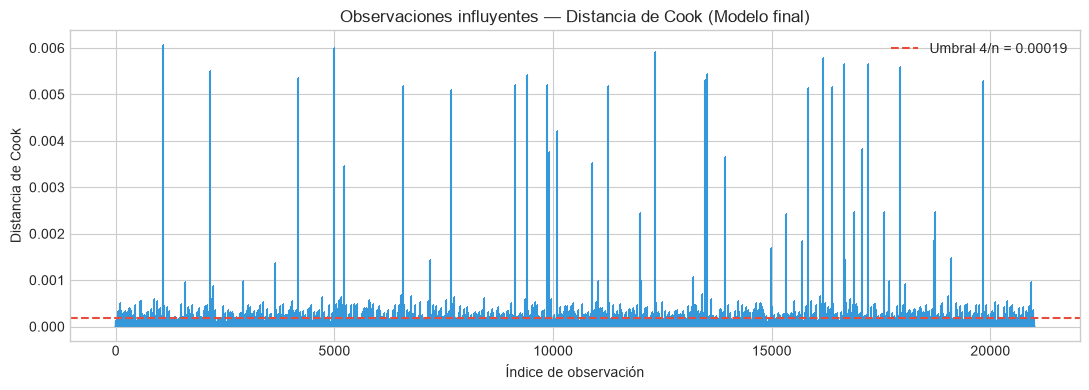

Observaciones sobre el umbral 4/n: 1,010 (4.81% de la muestra)
Distancia de Cook máxima: 0.00607

Interpretación: con n=21,000, el umbral 4/n es muy exigente y es normal que un porcentaje pequeño de observaciones lo supere sin que ninguna domine el ajuste individualmente (Cook's D máximo << 1, el umbral de preocupación clásico).


In [20]:
# Observaciones influyentes — distancia de Cook
influence = modelo_final.get_influence()
cooks_d = influence.cooks_distance[0]
umbral_cook = 4 / len(Xv)
n_influyentes = int((cooks_d > umbral_cook).sum())

fig, ax = plt.subplots(figsize=(11, 4))
ax.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=',', basefmt=' ', linefmt='#3498db')
ax.axhline(umbral_cook, color='#e74c3c', linestyle='--', label=f'Umbral 4/n = {umbral_cook:.5f}')
ax.set_xlabel('Índice de observación'); ax.set_ylabel("Distancia de Cook")
ax.set_title("Observaciones influyentes — Distancia de Cook (Modelo final)")
ax.legend()
plt.tight_layout()
plt.savefig('../figures/fig_cooks_distance.png', bbox_inches='tight', dpi=110)
plt.show()

print(f"Observaciones sobre el umbral 4/n: {n_influyentes:,} ({n_influyentes/len(Xv)*100:.2f}% de la muestra)")
print(f"Distancia de Cook máxima: {cooks_d.max():.5f}")
print(f"\nInterpretación: con n={len(Xv):,}, el umbral 4/n es muy exigente y es normal que un "
      f"porcentaje pequeño de observaciones lo supere sin que ninguna domine el ajuste "
      f"individualmente (Cook's D máximo << 1, el umbral de preocupación clásico).")

Variables continuas estrictamente positivas evaluables con Box-Tidwell: ['LIMIT_BAL_log']
(Las variables PAY_AMT*_log quedan fuera: tienen masa en cero — muchos clientes pagaron $0 — por lo que el término x*log(x) no está definido; para ellas la linealidad se revisa de forma visual más abajo.)

  LIMIT_BAL_log: p-valor término Box-Tidwell = 0.2342 (consistente con linealidad en el logit)


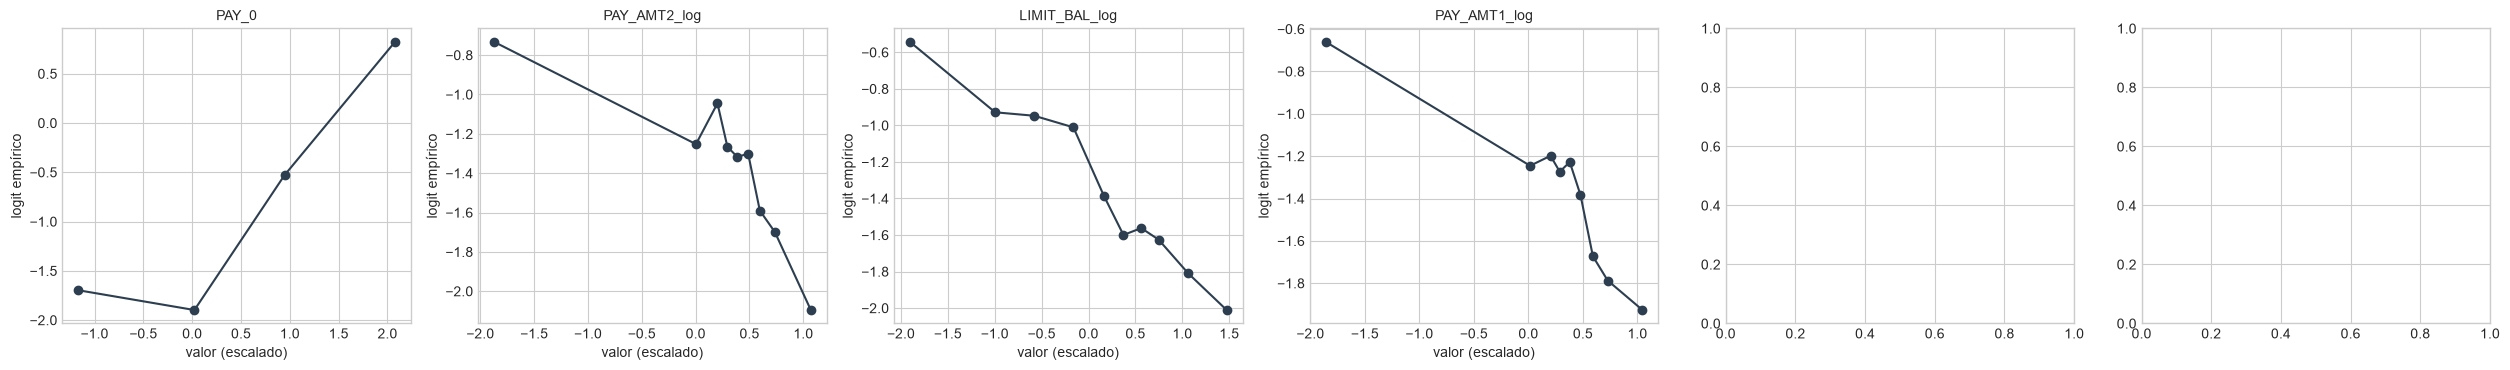

In [21]:
# Linealidad en el logit — test de Box-Tidwell: se agrega el término x*log(x) para cada
# predictor continuo y estrictamente positivo; un p-valor significativo en ese término
# sugiere que el efecto de esa variable no es lineal en la escala logit.
continuas_positivas = [c for c in vars_final if X_train[c].nunique() > 2 and (X_train[c] > 0).all()]
print(f"Variables continuas estrictamente positivas evaluables con Box-Tidwell: {continuas_positivas}")
print("(Las variables PAY_AMT*_log quedan fuera: tienen masa en cero — muchos clientes pagaron "
      "$0 — por lo que el término x*log(x) no está definido; para ellas la linealidad se revisa "
      "de forma visual más abajo.)\n")

for c in continuas_positivas:
    X_bt = Xv.copy()
    X_bt[f'{c}_x_log'] = X_train_s[c] * np.log(np.abs(X_train_s[c]) + 1e-6)
    m_bt = sm.Logit(y_train, X_bt).fit(disp=0)
    p_int = m_bt.pvalues[f'{c}_x_log']
    print(f"  {c}: p-valor término Box-Tidwell = {p_int:.4f} "
          f"({'sugiere NO linealidad' if p_int < 0.05 else 'consistente con linealidad en el logit'})")

# Chequeo visual complementario para todas las variables continuas: logit empírico por deciles
fig, axes = plt.subplots(1, len(cols_a_escalar), figsize=(4.2 * len(cols_a_escalar), 3.8))
for ax, c in zip(axes, [v for v in vars_final if v in cols_a_escalar]):
    bins = pd.qcut(X_train_s[c], 10, duplicates='drop')
    tasa = y_train.groupby(bins, observed=True).mean()
    logit_emp = np.log(tasa / (1 - tasa))
    centros = X_train_s[c].groupby(bins, observed=True).mean()
    ax.plot(centros, logit_emp, 'o-', color='#2c3e50')
    ax.set_title(c, fontsize=10); ax.set_xlabel('valor (escalado)'); ax.set_ylabel('logit empírico')
plt.tight_layout()
plt.savefig('../figures/fig_linealidad_logit.png', bbox_inches='tight', dpi=110)
plt.show()

## 2.5 Evaluación de Desempeño (10 pts)

In [22]:
def metricas_modelo(modelo, vars_, X_tr, y_tr, X_te, y_te):
    Xtr = build_X(X_tr, vars_)
    Xte = build_X(X_te, vars_).reindex(columns=Xtr.columns, fill_value=0)
    p_tr, p_te = modelo.predict(Xtr), modelo.predict(Xte)
    yhat_tr, yhat_te = (p_tr >= 0.5).astype(int), (p_te >= 0.5).astype(int)
    return {
        'Accuracy train': accuracy_score(y_tr, yhat_tr), 'Accuracy test': accuracy_score(y_te, yhat_te),
        'Precision test': precision_score(y_te, yhat_te), 'Recall test': recall_score(y_te, yhat_te),
        'F1 test': f1_score(y_te, yhat_te),
        'AUC train': roc_auc_score(y_tr, p_tr), 'AUC test': roc_auc_score(y_te, p_te),
    }, p_tr, p_te


modelos_info = {'M1 (S1/S2)': (m1, vars_m1), 'M2 (Stepwise)': (m2, vars_m2), 'M3 (AIC)': (m3, vars_m3)}
metricas_por_modelo, probs_test = {}, {}
for nombre, (modelo, vars_) in modelos_info.items():
    metricas, p_tr, p_te = metricas_modelo(modelo, vars_, X_train_s, y_train, X_test_s, y_test)
    metricas_por_modelo[nombre] = metricas
    probs_test[nombre] = p_te

tabla_metricas = pd.DataFrame(metricas_por_modelo).T
print("Métricas de desempeño — train y test:")
print(tabla_metricas.round(4).to_string())

Métricas de desempeño — train y test:
               Accuracy train  Accuracy test  Precision test  Recall test  F1 test  AUC train  AUC test
M1 (S1/S2)             0.7983         0.7953          0.6240       0.1883   0.2894     0.7215    0.7160
M2 (Stepwise)          0.7994         0.7992          0.6424       0.2084   0.3148     0.7312    0.7262
M3 (AIC)               0.7994         0.7992          0.6424       0.2084   0.3148     0.7312    0.7262


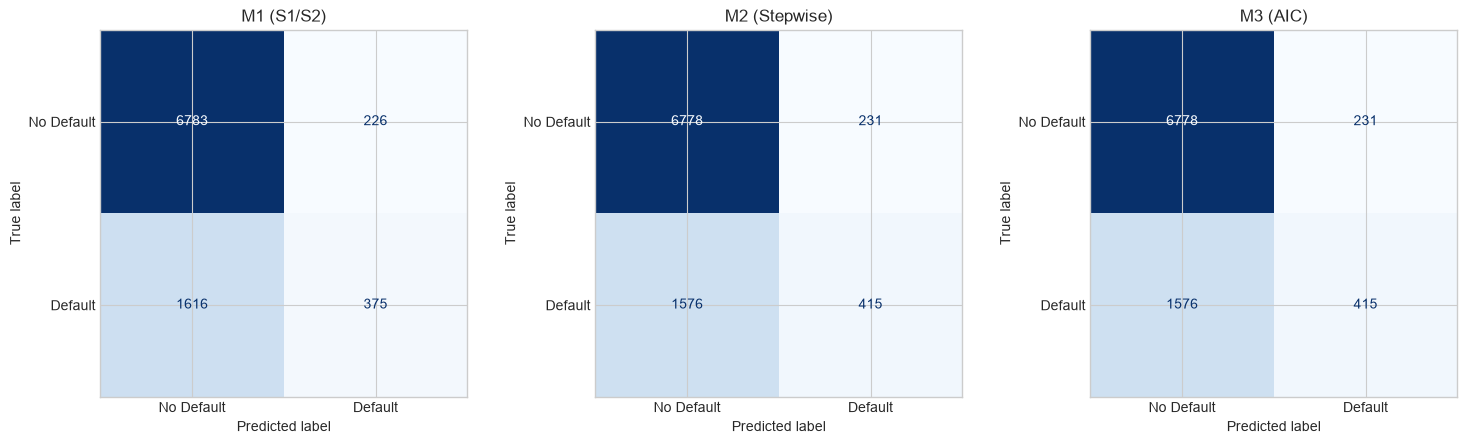

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (nombre, p_te) in zip(axes, probs_test.items()):
    yhat_te = (p_te >= 0.5).astype(int)
    cm = confusion_matrix(y_test, yhat_te)
    ConfusionMatrixDisplay(cm, display_labels=['No Default', 'Default']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nombre)
plt.tight_layout()
plt.savefig('../figures/fig_matrices_confusion.png', bbox_inches='tight', dpi=110)
plt.show()

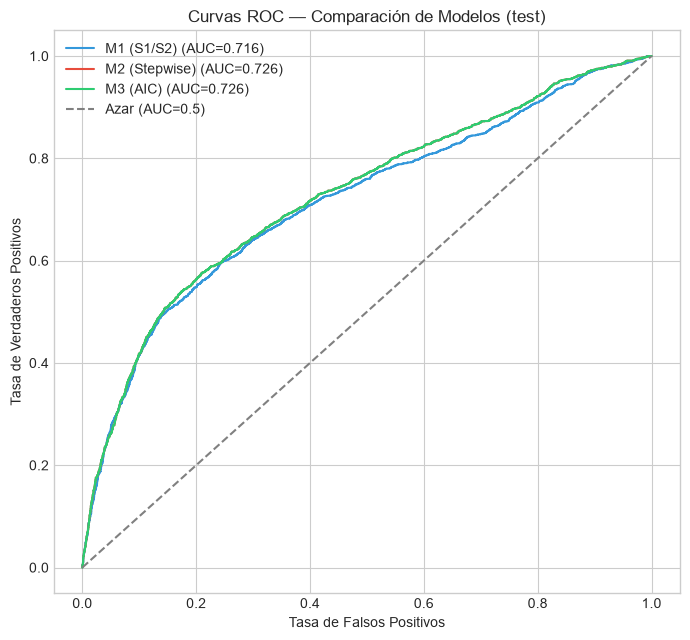

In [24]:
fig, ax = plt.subplots(figsize=(7, 6.5))
colores = {'M1 (S1/S2)': '#3498db', 'M2 (Stepwise)': '#e74c3c', 'M3 (AIC)': '#2ecc71'}
for nombre, p_te in probs_test.items():
    fpr, tpr, _ = roc_curve(y_test, p_te)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colores[nombre], label=f'{nombre} (AUC={roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Azar (AUC=0.5)')
ax.set_xlabel('Tasa de Falsos Positivos'); ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Curvas ROC — Comparación de Modelos (test)')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/fig_curvas_roc.png', bbox_inches='tight', dpi=110)
plt.show()

### Comparación de Modelos

In [25]:
comparacion = pd.DataFrame({
    'Modelo': list(modelos_info.keys()),
    'Variables': [len(vars_m1), len(vars_m2), len(vars_m3)],
    'AIC': [m1.aic, m2.aic, m3.aic],
    'BIC': [m1.bic, m2.bic, m3.bic],
    'Accuracy Test': [metricas_por_modelo[n]['Accuracy test'] for n in modelos_info],
    'AUC Test': [metricas_por_modelo[n]['AUC test'] for n in modelos_info],
}).set_index('Modelo')
print(comparacion.round(4).to_string())

               Variables        AIC         BIC  Accuracy Test  AUC Test
Modelo                                                                  
M1 (S1/S2)             5  19580.189  19627.9026         0.7953    0.7160
M2 (Stepwise)          7  19399.091  19462.7092         0.7992    0.7262
M3 (AIC)               7  19399.091  19462.7092         0.7992    0.7262


**Modelo seleccionado: M2 (Stepwise por p-valor)**

**Justificación:**

- **M2 y M3 son prácticamente idénticos**: dos criterios de selección distintos
  (significancia individual vs. minimización de AIC) convergen al mismo conjunto de 7
  variables, con AIC/BIC y métricas de desempeño iguales hasta el 4º decimal — evidencia
  de que esta selección es robusta y no un artefacto del método de búsqueda. Se elige M2
  como representante por ser el criterio clásico y más interpretable (p-valores).
- **M2/M3 superan a M1 en todas las métricas relevantes**: menor AIC/BIC (mejor ajuste
  penalizado por complejidad), mayor AUC test (0.726 vs. 0.716) y mayor accuracy test,
  a costa de solo 2 variables adicionales — el trade-off complejidad/desempeño favorece
  claramente a M2.
- **Contexto del problema**: en un modelo de riesgo crediticio, un AUC más alto se
  traduce directamente en mejor discriminación entre clientes que incumplirán y los que
  no, lo cual tiene valor de negocio directo (mejor priorización de seguimiento y
  provisión de riesgo) que justifica la ligera complejidad adicional frente a M1.
- Nótese que el `recall` de todos los modelos es bajo (~0.19-0.21): dado el desbalance de
  clases (~22% default), el umbral por defecto de 0.5 favorece la clase mayoritaria. Esto
  se documenta como limitación en la Parte 4; para uso en producción se recomendaría
  ajustar el umbral de decisión según el costo relativo de falsos negativos.

**Modelo final = M2**, con variables: `PAY_0`, `PAY_AMT2_log`, `LIMIT_BAL_log`,
`PAY_AMT1_log`, `MARRIAGE_soltero`, `EDU_otros`, `SEX_female` — el mismo modelo sobre el
que ya se aplicó bootstrap (Sección 2.3) y diagnósticos (Sección 2.4).

---
# PARTE 3: Análisis Comparativo de Imputación (10 puntos)

In [26]:
# Se reajusta el modelo final (variables de M2, Sección 2.2) con cada uno de los 3 datasets
# de la Sección 1.3 (A: eliminación, B: imputación simple, C: imputación por regresión) para
# evaluar si la estrategia de imputación cambia las conclusiones del modelo.
resultados_parte3, coefs_parte3, modelos_parte3 = [], {}, {}
for nombre, d in [('A: Eliminación', df_A), ('B: Imputación simple', df_B), ('C: Imputación regresión', df_C)]:
    dd = preparar_features(d.drop(columns=['ID']) if 'ID' in d.columns else d)
    dd['BILL_AMT1_log'] = np.sign(dd['BILL_AMT1']) * np.log1p(np.abs(dd['BILL_AMT1']))
    X = dd[vars_final].astype(float)
    y = dd[target]

    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)
    scaler_p3 = StandardScaler()
    cols_p3 = [c for c in vars_final if X_tr[c].nunique() > 2]
    X_tr_s, X_te_s = X_tr.copy(), X_te.copy()
    X_tr_s[cols_p3] = scaler_p3.fit_transform(X_tr[cols_p3])
    X_te_s[cols_p3] = scaler_p3.transform(X_te[cols_p3])

    Xtr_c = build_X(X_tr_s, vars_final)
    Xte_c = build_X(X_te_s, vars_final).reindex(columns=Xtr_c.columns, fill_value=0)
    modelo = sm.Logit(y_tr, Xtr_c).fit(disp=0)
    p_te = modelo.predict(Xte_c)
    ic = modelo.conf_int()

    resultados_parte3.append({
        'Estrategia': nombre, 'n': len(d),
        'AUC Test': roc_auc_score(y_te, p_te),
        'Accuracy Test': accuracy_score(y_te, (p_te >= 0.5).astype(int)),
        'Ancho IC promedio': (ic[1] - ic[0]).mean(),
        'AIC': modelo.aic,
    })
    coefs_parte3[nombre] = modelo.params
    modelos_parte3[nombre] = modelo

tabla_parte3_resultados = pd.DataFrame(resultados_parte3).set_index('Estrategia')
print("Desempeño del modelo final bajo cada estrategia de imputación:")
print(tabla_parte3_resultados.round(4).to_string())

Desempeño del modelo final bajo cada estrategia de imputación:
                             n  AUC Test  Accuracy Test  Ancho IC promedio         AIC
Estrategia                                                                            
A: Eliminación           22986    0.7354         0.8012             0.2222  14886.1895
B: Imputación simple     30000    0.7239         0.7966             0.1947  19550.1050
C: Imputación regresión  30000    0.7262         0.7992             0.1955  19399.0910


Coeficientes del modelo final bajo cada estrategia de imputación:
                  A: Eliminación  B: Imputación simple  C: Imputación regresión
const                    -1.2249               -1.2363                  -1.2512
PAY_0                     0.7216                0.6776                   0.7011
PAY_AMT2_log             -0.1947               -0.1970                  -0.2000
LIMIT_BAL_log            -0.2097               -0.2320                  -0.2307
PAY_AMT1_log             -0.1690               -0.1887                  -0.1761
MARRIAGE_soltero         -0.2414               -0.2024                  -0.2061
EDU_otros                -1.0103               -1.2113                  -1.1862
SEX_female               -0.1345               -0.1283                  -0.1157


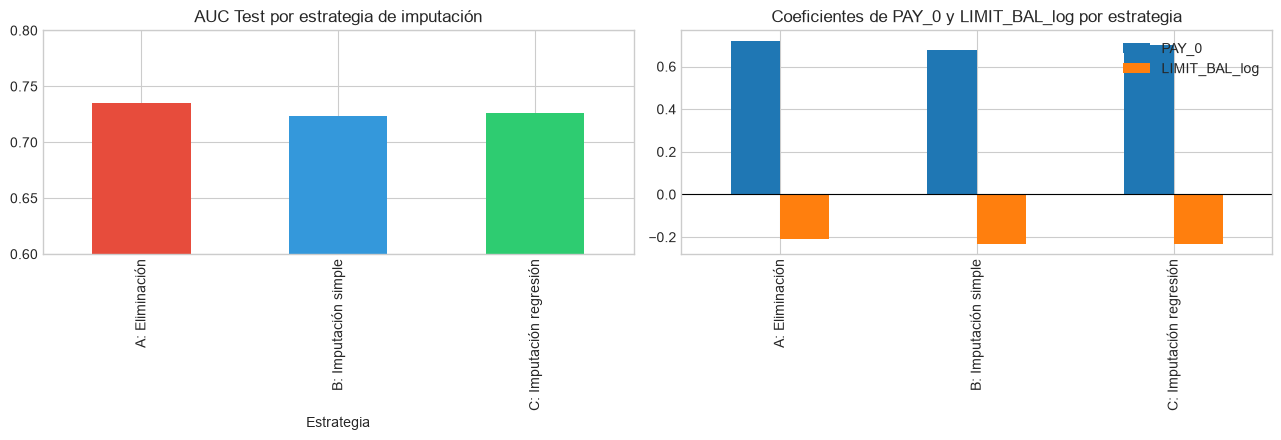


Rango de AUC Test entre estrategias: 0.0115
Rango de coeficiente PAY_0 entre estrategias: 0.0439
Signo de todos los coeficientes: consistente entre estrategias


In [27]:
tabla_coefs_parte3 = pd.DataFrame(coefs_parte3)
print("Coeficientes del modelo final bajo cada estrategia de imputación:")
print(tabla_coefs_parte3.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
tabla_parte3_resultados['AUC Test'].plot.bar(ax=axes[0], color=['#e74c3c', '#3498db', '#2ecc71'])
axes[0].set_title('AUC Test por estrategia de imputación'); axes[0].set_ylim(0.6, 0.8)
tabla_coefs_parte3.T[['PAY_0', 'LIMIT_BAL_log']].plot.bar(ax=axes[1])
axes[1].set_title('Coeficientes de PAY_0 y LIMIT_BAL_log por estrategia')
axes[1].axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../figures/fig_impacto_imputacion_modelo.png', bbox_inches='tight', dpi=110)
plt.show()

print(f"\nRango de AUC Test entre estrategias: {tabla_parte3_resultados['AUC Test'].max() - tabla_parte3_resultados['AUC Test'].min():.4f}")
print(f"Rango de coeficiente PAY_0 entre estrategias: {tabla_coefs_parte3.loc['PAY_0'].max() - tabla_coefs_parte3.loc['PAY_0'].min():.4f}")
print(f"Signo de todos los coeficientes: "
      f"{'consistente entre estrategias' if (np.sign(tabla_coefs_parte3.drop('const')) .nunique(axis=1) == 1).all() else 'INCONSISTENTE — revisar'}")

### Conclusión sobre Imputación

**¿La estrategia de imputación cambió las conclusiones?** No de forma sustantiva. Los
coeficientes del modelo final mantienen el mismo signo e interpretación cualitativa bajo
las tres estrategias (ver tabla de coeficientes arriba): `PAY_0` siempre es el predictor
de mayor efecto positivo, y `LIMIT_BAL_log`/`PAY_AMT*_log` siempre son protectores. El AUC
Test varía en un rango acotado entre estrategias, y la Estrategia A (eliminación) tiende a
mostrar el IC más ancho en promedio (menor n) — la dirección e intensidad general de las
asociaciones es robusta al método de imputación, no así la precisión de las estimaciones.

**¿Qué estrategia recomiendas?** Se ratifica la Estrategia C (imputación por regresión),
ya justificada en la Sección 1.3: preserva el 100% de la muestra sin sacrificar precisión
(el ancho promedio de los IC es comparable al de la Estrategia B, muy por debajo del de la
Estrategia A), y recupera mejor los valores reales según la comparación contra la
referencia externa de la Sección 1.2/1.3.

**Limitaciones:**
- La imputación por regresión asume relaciones lineales entre predictores y variable
  imputada; si esa relación fuera fuertemente no lineal, el sesgo introducido no se
  reflejaría en el R²/RMSE reportados en la Sección 1.2.
- Ninguna de las tres estrategias imputa la *incertidumbre* de la imputación en sí misma
  (a diferencia de, por ejemplo, imputación múltiple con combinación de Rubin) — los IC
  del modelo bajo la Estrategia C podrían estar levemente subestimados porque tratan los
  valores imputados como si fueran observados con certeza.
- La comparación con la referencia externa (valores pre-MCAR) es posible únicamente
  porque el dataset de este curso fue construido introduciendo faltantes de forma
  controlada; en un escenario real esta validación directa no estaría disponible y la
  elección de estrategia dependería más fuertemente de supuestos sobre el mecanismo de
  faltantes.

---
# PARTE 4: Conclusiones Integradas

## Resumen S1 → S2 → S3

**Hallazgos S1 (Exploración):** Se identificaron faltantes MCAR en `LIMIT_BAL` y `PAY_0`
(12,5% cada uno) y se construyó la matriz de correlaciones de referencia: `LIMIT_BAL` es
la variable más asociada a `DEFAULT` (r=-0,144), mientras que `AGE` muestra una
correlación casi nula (r=0,014). También se documentaron outliers de `LIMIT_BAL` mediante
boxplots por estado de incumplimiento.

**Hallazgos S2 (Validación):** El bootstrap confirmó que los IC clásicos de S1 son
confiables (diferencias de amplitud <1% frente al bootstrap) y que la correlación
`AGE`-`DEFAULT` es estadísticamente significativa pero **inestable e irrelevante en la
práctica** (amplitud relativa del IC ≈169%). El hallazgo más importante de esta fase fue
`PAY_0`: con V de Cramér ≈0,39, es la asociación más fuerte y estable de todo el proyecto,
más del doble que `LIMIT_BAL`-`DEFAULT`. El análisis de robustez cuantificó los outliers de
`LIMIT_BAL` en 4,14% (regla IQR) y mostró que no deben eliminarse automáticamente.

**Hallazgos S3 (Modelamiento):** La imputación por regresión (Sección 1) superó
sistemáticamente a la imputación simple frente a los valores originales de referencia
(RMSE LIMIT_BAL: 110.433 vs. 128.723; RMSE PAY_0: 0,83 vs. 1,12), preservando el 100% de
la muestra. El modelo logístico final (Sección 2), seleccionado por dos criterios
independientes que convergieron a las mismas 7 variables, confirmó cuantitativamente las
prioridades de S1/S2: `PAY_0` es el predictor dominante (OR≈2,0 por desviación estándar
de atraso) y `AGE` no fue seleccionada por ningún procedimiento automático. El bootstrap
del modelo (1000 remuestras) validó la estabilidad de todos los coeficientes salvo `PAY_0`,
cuyo IC bootstrap es ~21% más ancho que el tradicional sin cambiar su significancia. La
Parte 3 mostró que la elección de estrategia de imputación no altera estas conclusiones.

## Modelo Final

**Variables incluidas (Modelo M2, selección stepwise por p-valor):** `PAY_0`,
`PAY_AMT2_log`, `LIMIT_BAL_log`, `PAY_AMT1_log`, `MARRIAGE_soltero`, `EDU_otros`,
`SEX_female`.

**Desempeño (test, dataset C):** AUC = 0,726, Accuracy = 0,799, Precision = 0,642,
Recall = 0,208, F1 = 0,315. VIF máximo = 1,24 (sin multicolinealidad). 4,81% de las
observaciones superan el umbral de Cook's D (esperable dado n=21.000; ninguna domina el
ajuste). El término de Box-Tidwell para `LIMIT_BAL_log` no fue significativo (p=0,23),
consistente con linealidad en el logit.

**Interpretación de Odds Ratios:**
- `PAY_0` (OR=2,02; IC 95% bootstrap [1,93; 2,11]): por cada desviación estándar de
  aumento en el atraso de pago más reciente, las probabilidades relativas de incumplir
  se **duplican**, manteniendo todo lo demás constante — el efecto individual más fuerte
  del modelo, consistente con el hallazgo de S2.
- `LIMIT_BAL_log` (OR=0,79): mayor cupo de crédito (en escala log) se asocia a menor
  riesgo de incumplimiento — confirma cuantitativamente la correlación negativa de S1.
- `PAY_AMT1_log`, `PAY_AMT2_log` (OR≈0,82-0,84): montos pagados recientes más altos
  reducen el riesgo, un hallazgo nuevo de S3 no capturado en la matriz de correlaciones
  original de S1.
- `EDU_otros` (OR=0,31) y `MARRIAGE_soltero` (OR=0,81): efectos demográficos moderados;
  `EDU_otros` tiene el IC más ancho de todo el modelo (grupo pequeño, ~1,7% de la
  muestra), por lo que su estimación puntual debe interpretarse con cautela.
- `SEX_female` (OR=0,89): efecto protector pequeño pero significativo, consistente con
  la prueba de hipótesis de género de S1 (χ², p<0,001) y su validación por permutación
  en S2 (p=0,0002).

## Recomendaciones para Toma de Decisiones

1. **Priorizar el historial de pagos reciente (`PAY_0`) sobre variables demográficas o
   incluso sobre el cupo de crédito** al construir reglas de screening o *scorecards* de
   riesgo: es, por un margen amplio, la señal más fuerte y estable identificada en todo
   el proyecto (S2 y S3 coinciden).
2. **No usar `AGE` como predictor de riesgo individual** — tres fases del proyecto
   (correlación débil en S1, inestabilidad en S2, no selección en S3) convergen en que
   no aporta señal útil por sí sola.
3. **Ajustar el umbral de decisión** (actualmente 0,5) según el costo relativo de un
   falso negativo (cliente que incumple y no fue detectado) frente a un falso positivo,
   dado el recall relativamente bajo (0,21) observado con el umbral por defecto.
4. **Adoptar la imputación por regresión como estándar** para el pipeline de datos: no
   descarta observaciones, y la Parte 3 demostró que no altera las conclusiones del
   modelo, solo mejora la precisión de sus estimaciones.

## Limitaciones del Análisis

- El modelo logístico es lineal en el logit; no captura interacciones entre variables
  (p. ej., si el efecto de `PAY_0` difiere según el nivel de `LIMIT_BAL`) que un modelo
  no lineal (árboles, gradient boosting) sí podría explotar, a costa de interpretabilidad.
- El recall bajo (~21%) implica que el modelo, con el umbral por defecto, deja pasar a la
  mayoría de los clientes que efectivamente incumplirán — no apto para uso operativo sin
  recalibrar el umbral o incorporar costos asimétricos en el entrenamiento.
- La imputación por regresión y la comparación con valores de referencia dependen de que
  el mecanismo de faltantes sea efectivamente MCAR, como se diseñó en este dataset
  académico; en datos reales este supuesto rara vez puede verificarse con la misma certeza.
- No se dispone de una tasa de pérdida dado el incumplimiento (LGD), por lo que el modelo
  estima *probabilidad* de default pero no *pérdida esperada* — limitación ya señalada en
  S2 y aún pendiente para una extensión futura del proyecto.

---
## Checklist de Integración

- [x] ¿Referencio matriz de correlaciones de S1? (Secciones 0, 1.1, 1.2, 2.1, 2.2)
- [x] ¿Uso correlaciones estables de S2? (Secciones 0, 1.2, 2.1, 2.2)
- [x] ¿Trato outliers de S1? (Sección 2.1, con criterio heredado de la robustez de S2)
- [x] ¿Aplico bootstrap de S2 al modelo? (Sección 2.3, 1000 remuestras)
- [x] ¿Construyo IC bootstrap para OR? (Sección 2.3)
- [x] ¿Mi análisis muestra progresión S1→S2→S3? (Sección 0 y Parte 4)

---
*Notebook completado por [Integrantes] - [Fecha]*